#📌 Extracción

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

print("Datos cargados correctamente ✅")
print("Dimensiones del dataset:", df.shape)

print(df.head())

Datos cargados correctamente ✅
Dimensiones del dataset: (7267, 6)
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...

#🔧 Transformación

In [2]:
df.head()

print("Dimensiones:", df.shape)

print("Columnas:")
print(df.columns)

df.info()

print("\nEjemplo columna 'customer':")
print(df['customer'].iloc[0])

Dimensiones: (7267, 6)
Columnas:
Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Ejemplo columna 'customer':
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}


In [3]:
print(df.shape)
print(df.columns)

print(df.isnull().sum())
print((df.isnull().mean() * 100).round(2))

print(df.duplicated(subset=['customerID']).sum())
print(df['customerID'].duplicated().sum())

print(df['Churn'].unique())
df['Churn'] = df['Churn'].str.strip()
print(df['Churn'].unique())

df.info()

print(df['customer'].iloc[0])
print(df['account'].iloc[0])

(7267, 6)
Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64
customerID    0.0
Churn         0.0
customer      0.0
phone         0.0
internet      0.0
account       0.0
dtype: float64
0
0
['No' 'Yes' '']
['No' 'Yes' '']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}
{'Contract': 'One year', 'PaperlessBilling': 'Yes', 'PaymentMethod': '

In [4]:
df['Churn'] = df['Churn'].str.strip()
df = df[df['Churn'] != '']

df['Churn'] = df['Churn'].str.lower()

print(df['Churn'].unique())

df['customerID'] = df['customerID'].str.strip()

print(df.shape)

print(df['Churn'].value_counts())

print("Registros finales:", len(df))

['no' 'yes']
(7043, 6)
Churn
no     5174
yes    1869
Name: count, dtype: int64
Registros finales: 7043


In [5]:
df['Churn'] = df['Churn'].str.strip()
df = df[df['Churn'] != '']
df['Churn'] = df['Churn'].str.lower()

df['MonthlyCharges'] = df['account'].apply(lambda x: x['Charges']['Monthly'])

df['Cuentas_Diarias'] = df['MonthlyCharges'] / 30

print(df[['MonthlyCharges', 'Cuentas_Diarias']].head())

print(df[['MonthlyCharges', 'Cuentas_Diarias']].describe())

   MonthlyCharges  Cuentas_Diarias
0            65.6         2.186667
1            59.9         1.996667
2            73.9         2.463333
3            98.0         3.266667
4            83.9         2.796667
       MonthlyCharges  Cuentas_Diarias
count     7043.000000      7043.000000
mean        64.761692         2.158723
std         30.090047         1.003002
min         18.250000         0.608333
25%         35.500000         1.183333
50%         70.350000         2.345000
75%         89.850000         2.995000
max        118.750000         3.958333


In [6]:
df['Churn'] = df['Churn'].str.strip()
df = df[df['Churn'] != '']
df['Churn'] = df['Churn'].str.lower()

df['MonthlyCharges'] = df['account'].apply(lambda x: x['Charges']['Monthly'])
df['Cuentas_Diarias'] = df['MonthlyCharges'] / 30

df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})

df = df.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'MonthlyCharges': 'Cargos_Mensuales',
    'Cuentas_Diarias': 'Cargos_Diarios'
})

df['ID_Cliente'] = df['ID_Cliente'].str.strip()

print(df[['ID_Cliente', 'Evasion', 'Cargos_Mensuales', 'Cargos_Diarios']].head())
print(df[['Evasion']].value_counts())
print(df.dtypes)

   ID_Cliente  Evasion  Cargos_Mensuales  Cargos_Diarios
0  0002-ORFBO        0              65.6        2.186667
1  0003-MKNFE        0              59.9        1.996667
2  0004-TLHLJ        1              73.9        2.463333
3  0011-IGKFF        1              98.0        3.266667
4  0013-EXCHZ        1              83.9        2.796667
Evasion
0          5174
1          1869
Name: count, dtype: int64
ID_Cliente           object
Evasion               int64
customer             object
phone                object
internet             object
account              object
Cargos_Mensuales    float64
Cargos_Diarios      float64
dtype: object


#📊 Carga y análisis

In [8]:
df['TotalCharges'] = df['account'].apply(lambda x: x['Charges']['Total'])
df['tenure'] = df['customer'].apply(lambda x: x['tenure'])

df['Cargos_Mensuales'] = pd.to_numeric(df['Cargos_Mensuales'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

variables_numericas = ['tenure', 'Cargos_Mensuales', 'TotalCharges', 'Cargos_Diarios']

print(df[variables_numericas].describe())
print("\nMediana:")
print(df[variables_numericas].median())
print("\nDesviación estándar:")
print(df[variables_numericas].std())

print("\nValores nulos:")
print(df[variables_numericas].isnull().sum())

            tenure  Cargos_Mensuales  TotalCharges  Cargos_Diarios
count  7043.000000       7043.000000   7032.000000     7043.000000
mean     32.371149         64.761692   2283.300441        2.158723
std      24.559481         30.090047   2266.771362        1.003002
min       0.000000         18.250000     18.800000        0.608333
25%       9.000000         35.500000    401.450000        1.183333
50%      29.000000         70.350000   1397.475000        2.345000
75%      55.000000         89.850000   3794.737500        2.995000
max      72.000000        118.750000   8684.800000        3.958333

Mediana:
tenure                29.000
Cargos_Mensuales      70.350
TotalCharges        1397.475
Cargos_Diarios         2.345
dtype: float64

Desviación estándar:
tenure                24.559481
Cargos_Mensuales      30.090047
TotalCharges        2266.771362
Cargos_Diarios         1.003002
dtype: float64

Valores nulos:
tenure               0
Cargos_Mensuales     0
TotalCharges        11
Cargos

/tmp/ipykernel_5301/223481252.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Evasion', palette=colores, ax=axes[0])
/tmp/ipykernel_5301/223481252.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(etiquetas)


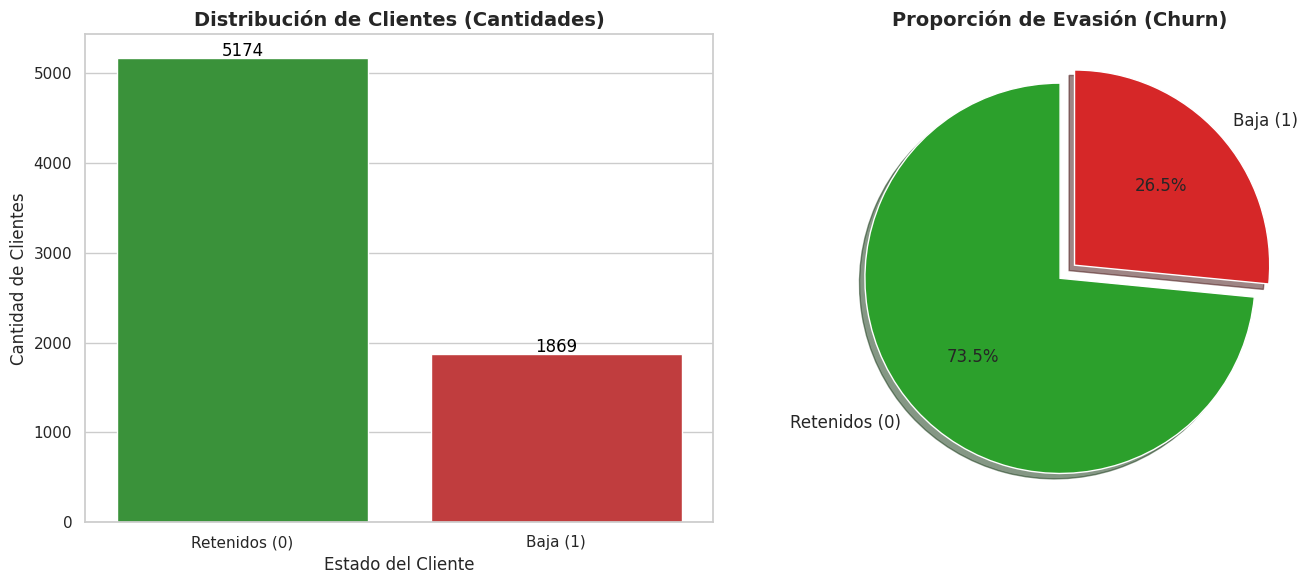

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Etiquetas para la variable Evasion (0 = Retenido, 1 = Baja)
etiquetas = ['Retenidos (0)', 'Baja (1)']
colores = ['#2ca02c', '#d62728'] # Verde para retenidos, rojo para bajas

# 1. Gráfico de Barras (Cantidades)
sns.countplot(data=df, x='Evasion', palette=colores, ax=axes[0])
axes[0].set_title('Distribución de Clientes (Cantidades)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Estado del Cliente', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)
axes[0].set_xticklabels(etiquetas)

# Agregar las etiquetas de datos sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), 
                     textcoords='offset points')

# 2. Gráfico de Pastel (Proporciones)
evasion_counts = df['Evasion'].value_counts()
axes[1].pie(evasion_counts, labels=etiquetas, autopct='%1.1f%%', startangle=90, 
            colors=colores, explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Evasión (Churn)', fontsize=14, fontweight='bold')

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()

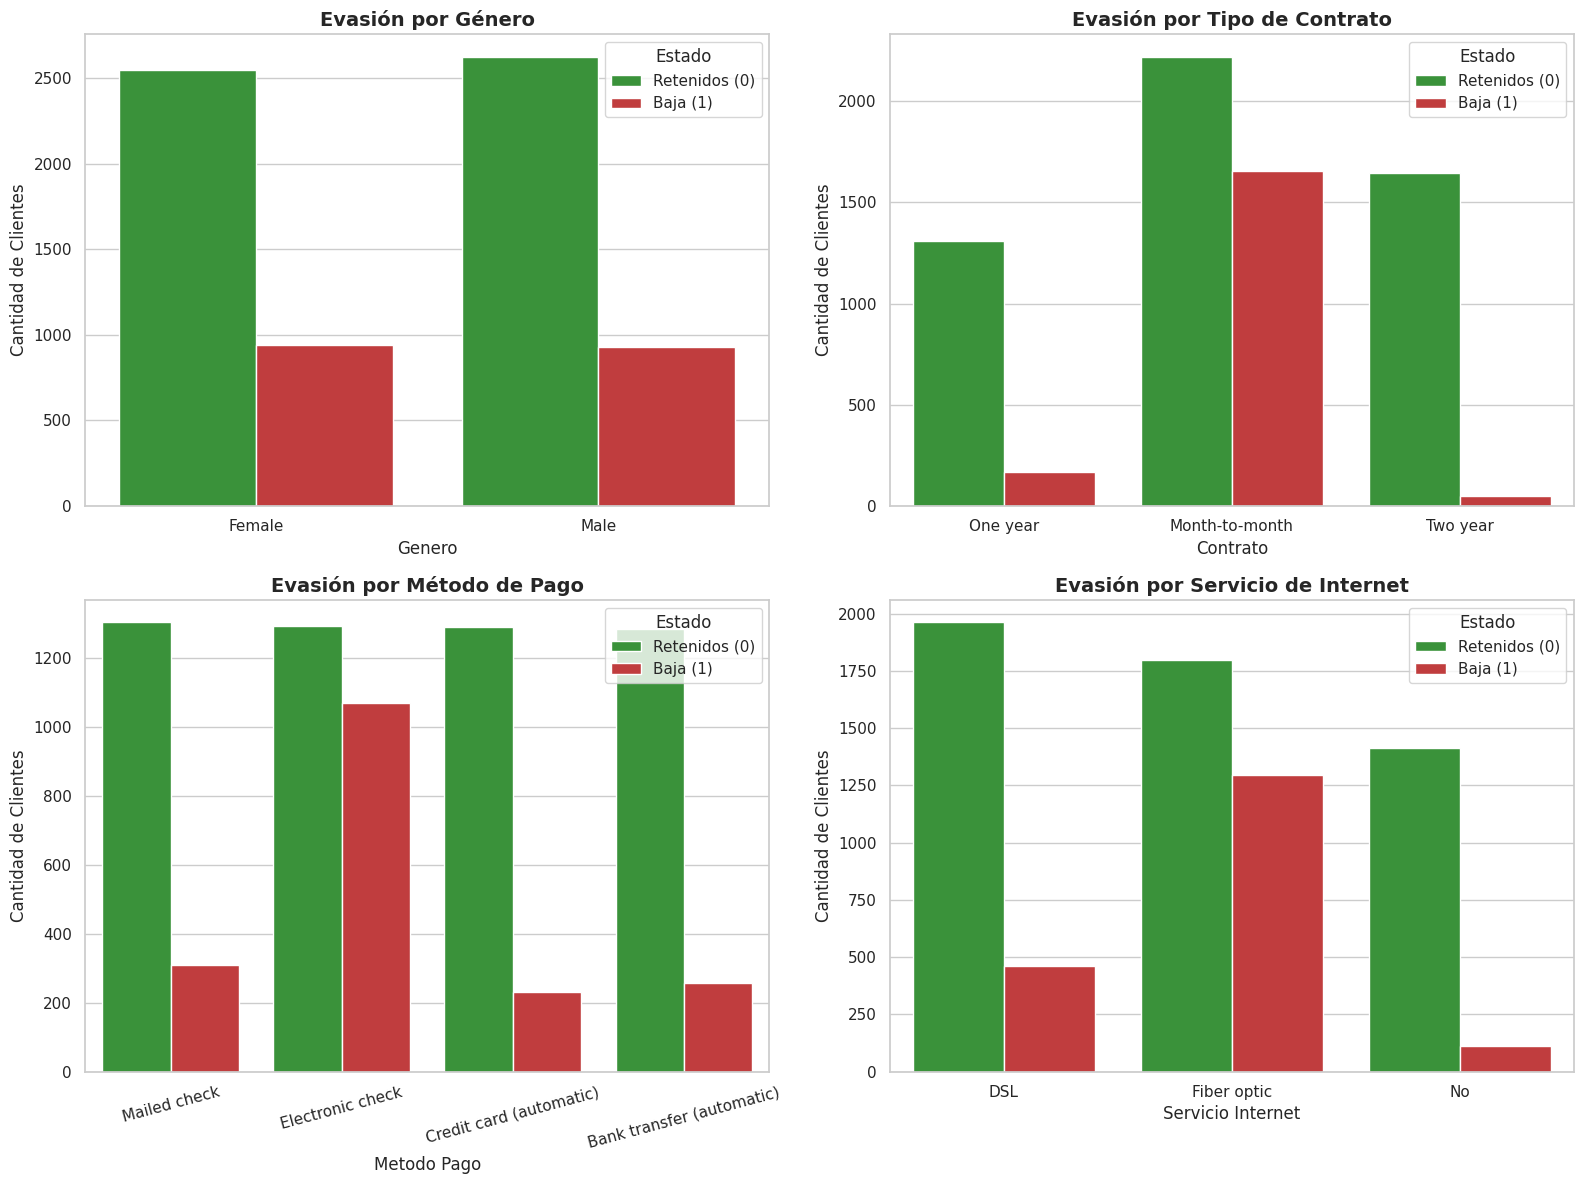

In [10]:

# 1. Extraer variables categóricas de los diccionarios anidados
df['Genero'] = df['customer'].apply(lambda x: x.get('gender'))
df['Contrato'] = df['account'].apply(lambda x: x.get('Contract'))
df['Metodo_Pago'] = df['account'].apply(lambda x: x.get('PaymentMethod'))
df['Servicio_Internet'] = df['internet'].apply(lambda x: x.get('InternetService'))

# 2. Configurar el estilo visual
sns.set_theme(style="whitegrid")
colores = ['#2ca02c', '#d62728'] # Verde = Retenido (0), Rojo = Baja (1)

# 3. Crear una figura con 4 subgráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Lista de variables y sus títulos para iterar
variables_cat = ['Genero', 'Contrato', 'Metodo_Pago', 'Servicio_Internet']
titulos = [
    'Evasión por Género', 
    'Evasión por Tipo de Contrato', 
    'Evasión por Método de Pago', 
    'Evasión por Servicio de Internet'
]

# 4. Generar los gráficos dinámicamente
for i, var in enumerate(variables_cat):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Crear el gráfico de barras agrupado
    sns.countplot(data=df, x=var, hue='Evasion', palette=colores, ax=ax)
    
    # Configuraciones de texto y ejes
    ax.set_title(titulos[i], fontsize=14, fontweight='bold')
    ax.set_xlabel(var.replace('_', ' '), fontsize=12)
    ax.set_ylabel('Cantidad de Clientes', fontsize=12)
    
    # Añadir leyenda descriptiva
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=['Retenidos (0)', 'Baja (1)'], title='Estado')
    
    # Rotar las etiquetas en el gráfico de Método de Pago para que no se superpongan
    if var == 'Metodo_Pago':
        ax.tick_params(axis='x', rotation=15)

# Ajustar diseño para que no se corten los textos y mostrar
plt.tight_layout()
plt.show()

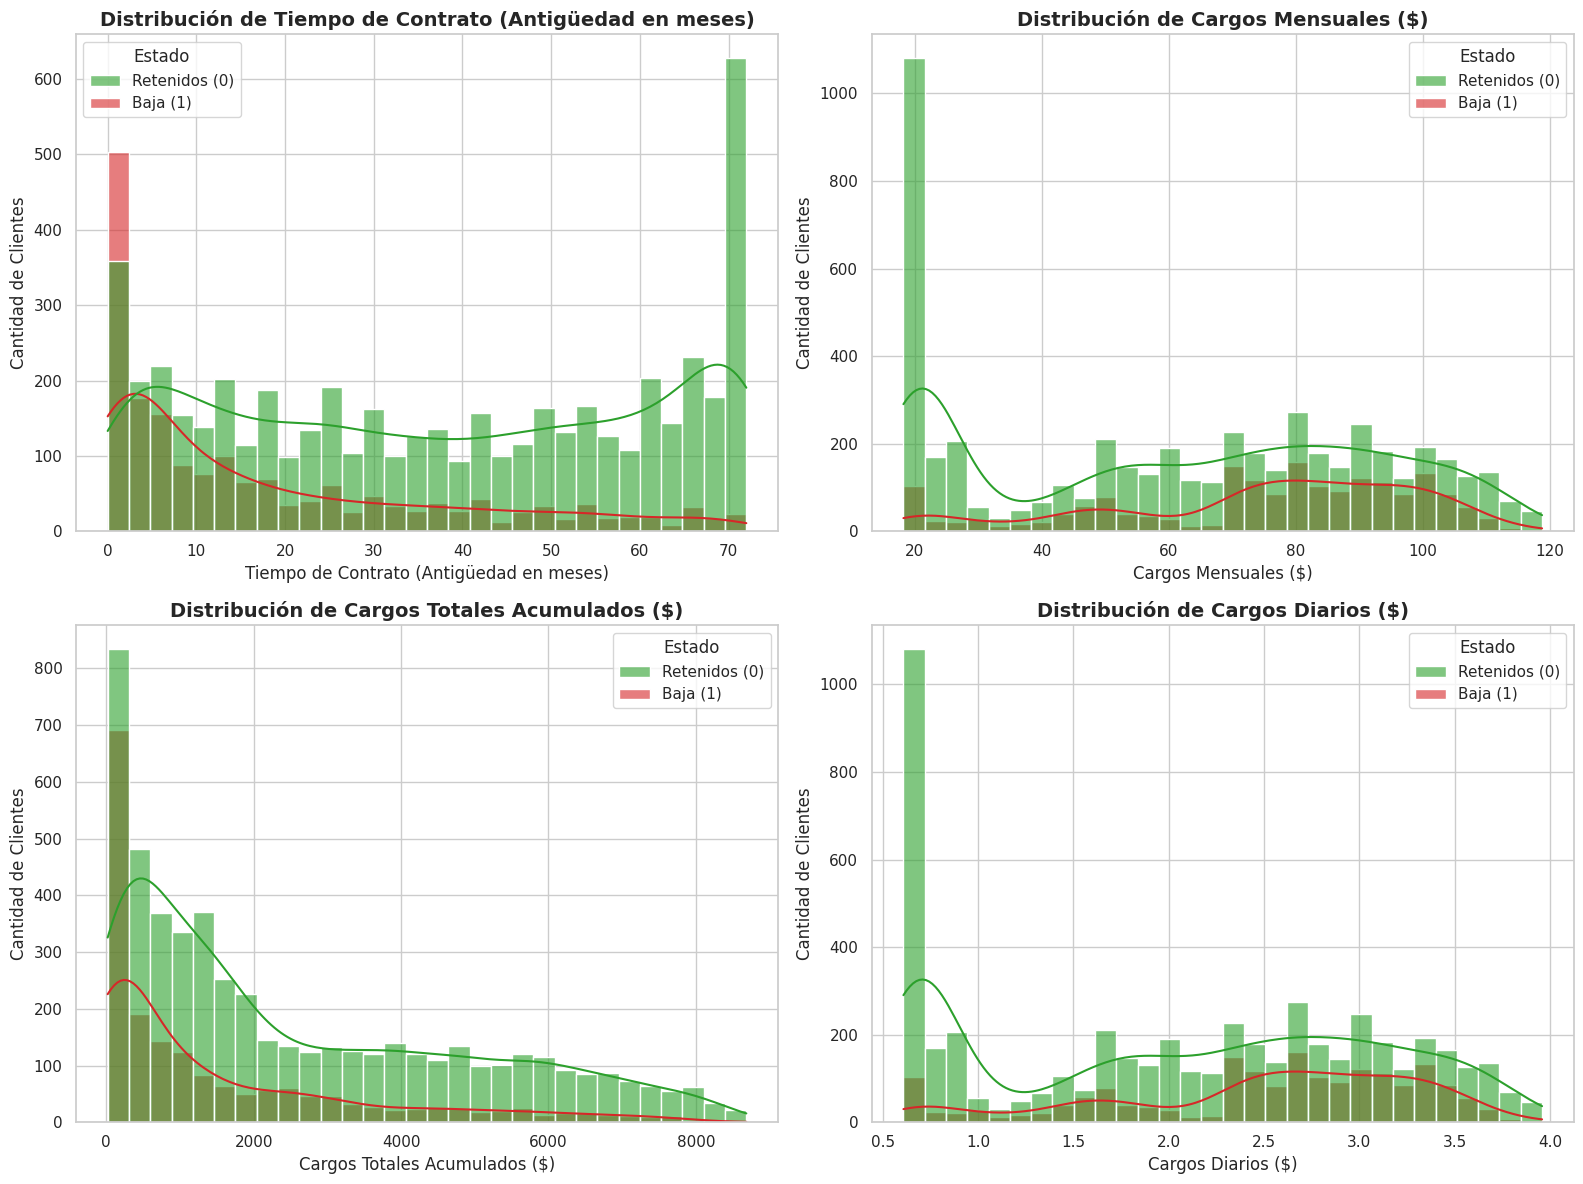

In [12]:

# 1. Definir las variables numéricas a analizar y sus títulos para los gráficos
variables_num = ['tenure', 'Cargos_Mensuales', 'TotalCharges', 'Cargos_Diarios']
titulos_num = [
    'Tiempo de Contrato (Antigüedad en meses)', 
    'Cargos Mensuales ($)', 
    'Cargos Totales Acumulados ($)', 
    'Cargos Diarios ($)'
]

# 2. Configurar el estilo
sns.set_theme(style="whitegrid")
colores = ['#2ca02c', '#d62728'] # Verde = Retenido (0), Rojo = Baja (1)

# 3. Crear una figura con 4 subgráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 4. Generar los gráficos de distribución dinámicamente
for i, var in enumerate(variables_num):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Crear el histograma con curva de densidad (KDE)
    sns.histplot(data=df, x=var, hue='Evasion', kde=True, palette=colores, 
                 ax=ax, bins=30, alpha=0.6)
    
    # Configuraciones de texto y ejes
    ax.set_title(f'Distribución de {titulos_num[i]}', fontsize=14, fontweight='bold')
    ax.set_xlabel(titulos_num[i], fontsize=12)
    ax.set_ylabel('Cantidad de Clientes', fontsize=12)
    
    # Ajustar la leyenda
    if ax.get_legend() is not None:
        ax.get_legend().set_title('Estado')
        for t, l in zip(ax.get_legend().texts, ['Retenidos (0)', 'Baja (1)']):
            t.set_text(l)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

#📄Informe final


##  Introducción
El presente informe detalla el proceso de Extracción, Transformación, Carga (ETL) y el Análisis Exploratorio de Datos (EDA) realizado sobre la base de clientes de **TelecomX LATAM**. El objetivo principal es comprender el comportamiento de **evasión (Churn)**, cuantificar la fuga de clientes e identificar los factores subyacentes que motivan esta decisión para orientar futuras estrategias de retención.

---

##  Limpieza y Tratamiento de Datos
El dataset original en formato JSON contaba con **7,267 registros**. Durante la fase de preparación, se realizaron las siguientes operaciones críticas:

* **Limpieza de la Variable Objetivo:** Se detectaron 224 registros con valores vacíos en la columna `Churn`. Al eliminarlos, obtuvimos un dataset limpio de **7,043 clientes válidos**. Posteriormente, la variable se binarizó (`yes` = 1, `no` = 0) y se renombró a `Evasion`.
* **Desanidado de Datos Complejos:** Se extrajo información vital que venía anidada en diccionarios (`customer`, `account`, `internet`), creando variables independientes como `Cargos_Mensuales` y `tenure` (antigüedad).
* **Ingeniería de Características:** Se derivó la métrica `Cargos_Diarios` (dividiendo el cargo mensual entre 30) para granularidad financiera.
* **Manejo de Nulos:** Al convertir `TotalCharges` a formato numérico, se identificaron **11 valores nulos**. Estos corresponden a clientes con `tenure = 0` (nuevos ingresos que aún no han completado su primer ciclo de facturación).

---

##  Análisis Exploratorio de Datos (EDA)
Las métricas descriptivas y las visualizaciones nos revelaron los siguientes patrones:

1. **Tasa de Evasión General:** * De los 7,043 clientes analizados, **1,869 (26.5%)** cancelaron su servicio, mientras que **5,174 (73.5%)** permanecieron activos. 

2. **Impacto de las Variables Categóricas:**
   * **Contrato:** La gran mayoría de las bajas provienen de clientes con modalidad **"Month-to-month"** (mes a mes). Los contratos a 1 o 2 años presentan tasas de retención sumamente sólidas.
   * **Servicio de Internet:** Los clientes con **Fibra Óptica (Fiber optic)** presentan una tasa de evasión preocupantemente superior en comparación con aquellos que utilizan DSL o no tienen internet.
   * **Método de Pago:** El uso del **Cheque Electrónico (Electronic check)** está fuertemente correlacionado con la cancelación del servicio, superando con creces a otros métodos como tarjeta de crédito o transferencia bancaria.
   * **Género:** La distribución de evasión es prácticamente simétrica entre hombres y mujeres, indicando que el género no es un factor determinante.

3. **Impacto de las Variables Numéricas:**
   * **Antigüedad (`tenure`):** El promedio de permanencia es de 32.37 meses. Sin embargo, la curva de distribución muestra un **pico crítico de evasión en los primeros 1 a 5 meses**. Por el contrario, los clientes retenidos muestran un fuerte pico de lealtad al acercarse a los 70-72 meses.
   * **Cargos (`MonthlyCharges`):** El gasto mensual promedio es de \$64.76. Los gráficos revelan que los clientes con facturas mensuales altas (entre **\$70 y \$110**) son mucho más propensos a cancelar que aquellos con planes básicos (cercanos a \$20).

---

##  Conclusiones e Insights
* **El Perfil de Alto Riesgo:** El cliente con mayor probabilidad de abandonar la empresa es aquel de reciente ingreso (menos de 6 meses), que contrata fibra óptica bajo un esquema mes a mes, paga facturas altas (+\$70) y utiliza cheque electrónico como método de pago.
* **Sensibilidad al Precio vs. Calidad:** La alta fuga en el servicio más costoso (Fibra Óptica) sugiere un desajuste entre el precio que paga el cliente y el valor percibido, ya sea por problemas técnicos de la red o deficiente atención al cliente.
* **El Compromiso es Clave:** La ausencia de barreras de salida en los contratos "mes a mes" facilita que el cliente abandone ante la menor fricción.

---

##  Recomendaciones Estratégicas
1. **Fomentar la Migración de Contratos:** Diseñar campañas agresivas de *upselling* que ofrezcan descuentos o *perks* (ej. streaming gratuito por meses) a los clientes de fibra óptica para que cambien su contrato de "mes a mes" a uno anual.
2. **Revisión Técnica y de Precios en Fibra Óptica:** El equipo de operaciones debe auditar la calidad y estabilidad de la fibra óptica. Si el servicio es estable, el equipo de marketing debe evaluar si el precio está fuera de mercado en comparación con la competencia local.
3. **Optimizar el Método de Pago:** Eliminar la fricción mensual del pago. Ofrecer incentivos (como un 5% de descuento en la factura) para que los clientes que usan "Cheque Electrónico" afilien sus pagos a débito automático con tarjeta de crédito.
4. **Programa de Onboarding (0-6 meses):** Implementar un seguimiento proactivo de servicio al cliente durante los primeros 5 meses de vida del usuario, resolviendo dudas de facturación o problemas de conexión antes de que se conviertan en motivos de cancelación.